In [20]:
# Import core libraries for data processing and EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries for pipeline, models, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Set professional visualization aesthetics
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [22]:
# 1. Load the dataset
# Ensure you have your dataset named 'car_data.csv' in your folder
df = pd.read_csv('dataset/sample_cars.csv' , encoding='utf-8')
df

,price,year,odometer,make,model,fuel,transmission,condition,engine_cc,power_hp,seats,body_type,state,title,description,seller_type
0,2588408,2020,80181,Kia,Sportage,hybrid,cvt,fair,1800,166,7,suv,Islamabad Capital Territory,Kia Sportage 2020 cvt,"Islamabad Capital Territory registered, 80181 ...",individual
1,287399,2007,266292,Hyundai,Elantra,cng,manual,like new,1200,120,4,suv,Sindh,Hyundai Elantra 2007 manual,"Sindh registered, 266292 km driven, like new c...",dealer
2,1052291,2017,140475,Honda,Civic,petrol,manual,like new,1000,112,7,sedan,Balochistan,Honda Civic 2017 manual,"Balochistan registered, 140475 km driven, like...",individual
3,849074,2014,171233,Nissan,Dayz,hybrid,automatic,good,1200,113,7,hatchback,Balochistan,Nissan Dayz 2014 automatic,"Balochistan registered, 171233 km driven, good...",dealer
4,848027,2015,146308,Hyundai,Elantra,diesel,automatic,fair,800,87,5,suv,Balochistan,Hyundai Elantra 2015 automatic,"Balochistan registered, 146308 km driven, fair...",dealer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,900760,2016,149721,Suzuki,Wagon R,diesel,automatic,good,1800,174,5,hatchback,KPK,Suzuki Wagon R 2016 automatic,"KPK registered, 149721 km driven, good condition.",individual
216,611352,2013,177820,Toyota,Aqua,diesel,manual,good,1200,125,7,sedan,Punjab,Toyota Aqua 2013 manual,"Punjab registered, 177820 km driven, good cond...",dealer
217,901894,2015,160482,Suzuki,Alto,diesel,cvt,good,1000,89,7,hatchback,Islamabad Capital Territory,Suzuki Alto 2015 cvt,"Islamabad Capital Territory registered, 160482...",individual
218,807860,2017,112494,Suzuki,Alto,diesel,cvt,good,660,50,4,sedan,Balochistan,Suzuki Alto 2017 cvt,"Balochistan registered, 112494 km driven, good...",dealer


In [23]:
# 2. Data Cleaning Strategy
# Drop text-heavy or high-cardinality columns that overcomplicate a baseline model
columns_to_drop = ['model', 'description', 'title', 'state']
df.drop(columns=columns_to_drop, axis=1, inplace=True, errors='ignore')

# Drop missing values to keep the pipeline clean for now
df.dropna(inplace=True)

print(f"Dataset shape after cleaning: {df.shape}")
df.head()

Dataset shape after cleaning: (220, 12)


,price,year,odometer,make,fuel,transmission,condition,engine_cc,power_hp,seats,body_type,seller_type
0,2588408,2020,80181,Kia,hybrid,cvt,fair,1800,166,7,suv,individual
1,287399,2007,266292,Hyundai,cng,manual,like new,1200,120,4,suv,dealer
2,1052291,2017,140475,Honda,petrol,manual,like new,1000,112,7,sedan,individual
3,849074,2014,171233,Nissan,hybrid,automatic,good,1200,113,7,hatchback,dealer
4,848027,2015,146308,Hyundai,diesel,automatic,fair,800,87,5,suv,dealer


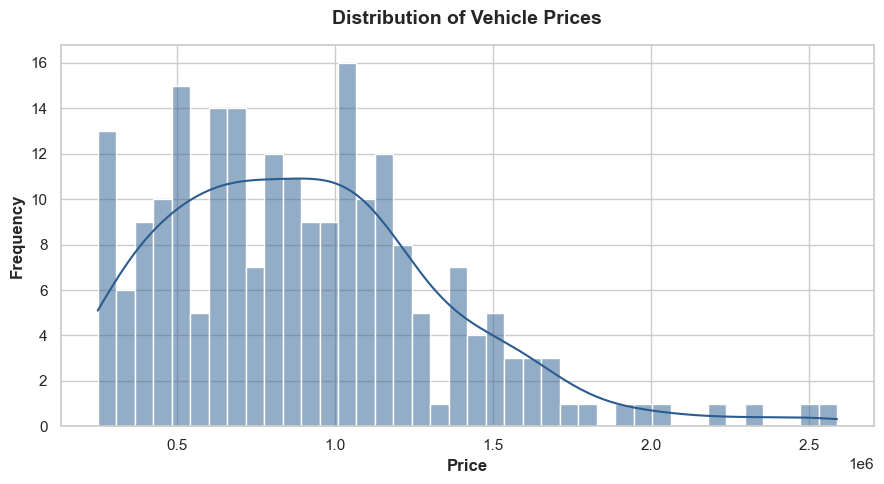

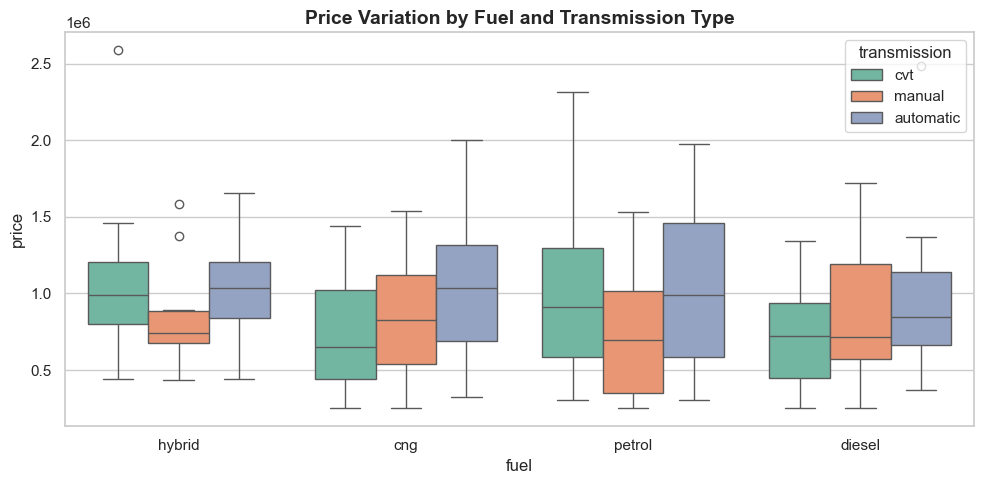

In [24]:
# Visualize the distribution of the Target Variable (Price)
plt.figure(figsize=(9, 5))
sns.histplot(df['price'], kde=True, color='#2b5c8f', bins=40)
plt.title('Distribution of Vehicle Prices', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Price', fontsize=12, fontweight='semibold')
plt.ylabel('Frequency', fontsize=12, fontweight='semibold')
plt.tight_layout()
plt.show()

# Price vs Transmission and Fuel Type
plt.figure(figsize=(10, 5))
sns.boxplot(x='fuel', y='price', hue='transmission', data=df, palette='Set2')
plt.title('Price Variation by Fuel and Transmission Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Create 'car_age' from the 'year' column (assuming current year is 2026)
current_year = 2026
df['car_age'] = current_year - df['year']

# Drop the original 'year' column as it's now represented by 'car_age'
df.drop('year', axis=1, inplace=True)

# Define Features (X) and Target (y)
X = df.drop('price', axis=1)
y = df['price']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Separate numerical and categorical columns for the transformer
num_cols = ['odometer', 'engine_cc', 'power_hp', 'seats', 'car_age']
cat_cols = ['make', 'fuel', 'transmission', 'condition', 'body_type', 'seller_type']

# Create the preprocessing engine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ])

# Pipeline 1: Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Pipeline 2: XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

# Train models
print("Training ensemble pipelines...")
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)
print("Training complete!")

Training ensemble pipelines...
Training complete!


In [27]:
# Evaluate Random Forest
rf_preds = rf_pipeline.predict(X_test)
rf_r2 = r2_score(y_test, rf_preds)

# Evaluate XGBoost
xgb_preds = xgb_pipeline.predict(X_test)
xgb_r2 = r2_score(y_test, xgb_preds)

print("--- Model Performance (R2 Score) ---")
print(f"Random Forest: {rf_r2:.4f}")
print(f"XGBoost:       {xgb_r2:.4f}")

# XGBoost is highly optimized for this type of tabular regression.

--- Model Performance (R2 Score) ---
Random Forest: 0.8912
XGBoost:       0.8519


In [28]:
# Save the winning XGBoost pipeline
joblib.dump(xgb_pipeline, 'vehicle_pricing_engine.joblib')
print("Model saved successfully as 'vehicle_pricing_engine.joblib'")

Model saved successfully as 'vehicle_pricing_engine.joblib'
